In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

PROJECT_ROOT = Path("D:/Ahmed/Credit_Loan_Risk")

X_train = pd.read_csv(PROJECT_ROOT / "Dataset" / "X_train.csv")
X_test  = pd.read_csv(PROJECT_ROOT / "Dataset" / "X_test.csv")
y_train = pd.read_csv(PROJECT_ROOT / "Dataset" / "y_train.csv").squeeze()
y_test  = pd.read_csv(PROJECT_ROOT / "Dataset" / "y_test.csv").squeeze()
scaler  = joblib.load(PROJECT_ROOT / "Dataset" / "robust_scaler.pkl")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train default rate: {y_train.mean():.4f}")

X_train: (246005, 59), X_test: (61502, 59)
y_train default rate: 0.0807


In [3]:
from sklearn.preprocessing import RobustScaler


X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # apply to test

# Convert back to dataframe to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print("Scaling done.")
print(X_train_scaled.describe().T[["mean", "50%", "std"]].head(10))

Scaling done.
                                mean  50%       std
NAME_CONTRACT_TYPE         -0.095014  0.0  0.293235
CODE_GENDER                 0.341786  0.0  0.474309
CNT_CHILDREN                0.417288  0.0  0.717709
AMT_INCOME_TOTAL            0.243425  0.0  0.922187
AMT_CREDIT                  0.151068  0.0  0.726185
AMT_ANNUITY                 0.110805  0.0  0.756082
NAME_EDUCATION_TYPE         0.509380  0.0  0.874751
REGION_POPULATION_RELATIVE  0.107935  0.0  0.741210
DAYS_BIRTH                  0.039952  0.0  0.600172
DAYS_EMPLOYED               0.330943  0.0  1.168567


**MODELS**

**LOGISTIC REGRESSION (BASELINE)**

=== Baseline Logistic Regression ===
ROC-AUC: 0.7461
              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56537
     Default       0.46      0.01      0.02      4965

    accuracy                           0.92     61502
   macro avg       0.69      0.50      0.49     61502
weighted avg       0.88      0.92      0.88     61502



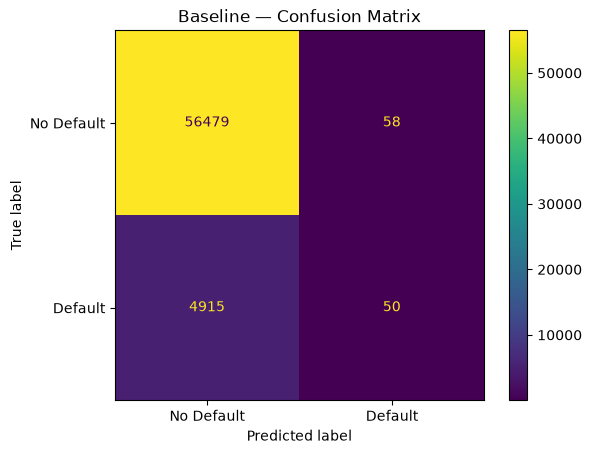

In [7]:
# ------------------------------------------------------------------
#  Baseline Logistic Regression (no imbalance handling)
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

lr_baseline = LogisticRegression(max_iter=1000, random_state=912)
lr_baseline.fit(X_train_scaled, y_train)

y_pred_baseline    = lr_baseline.predict(X_test_scaled)
y_proba_baseline   = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print("=== Baseline Logistic Regression ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Baseline — Confusion Matrix")
plt.show()

**LOGISTIC REGRESSION (CLASS WEIGHTING)**

=== Class Weighted Logistic Regression ===
ROC-AUC: 0.7459
              precision    recall  f1-score   support

  No Default       0.96      0.68      0.80     56537
     Default       0.16      0.68      0.26      4965

    accuracy                           0.68     61502
   macro avg       0.56      0.68      0.53     61502
weighted avg       0.90      0.68      0.75     61502



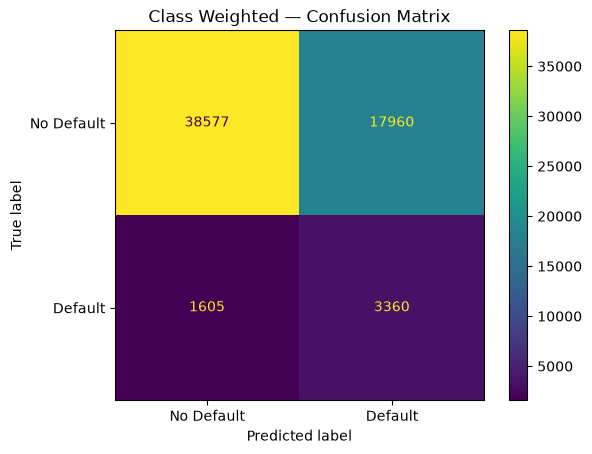

In [8]:
# ------------------------------------------------------------------
#  Class Weighted Logistic Regression
# ------------------------------------------------------------------
lr_weighted = LogisticRegression(max_iter=1000, random_state=912, class_weight={0: 0.08, 1: 0.92})
lr_weighted.fit(X_train_scaled, y_train)

y_pred_weighted  = lr_weighted.predict(X_test_scaled)
y_proba_weighted = lr_weighted.predict_proba(X_test_scaled)[:, 1]

print("=== Class Weighted Logistic Regression ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_weighted):.4f}")
print(classification_report(y_test, y_pred_weighted, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_weighted)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Class Weighted — Confusion Matrix")
plt.show()

**LOGISTIC REGRESSION (SMOTE)**

After SMOTE — Train shape: (452290, 59)
Class distribution: {0: 226145, 1: 226145}

=== SMOTE Logistic Regression ===
ROC-AUC: 0.7407
              precision    recall  f1-score   support

  No Default       0.96      0.69      0.80     56537
     Default       0.16      0.67      0.26      4965

    accuracy                           0.69     61502
   macro avg       0.56      0.68      0.53     61502
weighted avg       0.89      0.69      0.76     61502



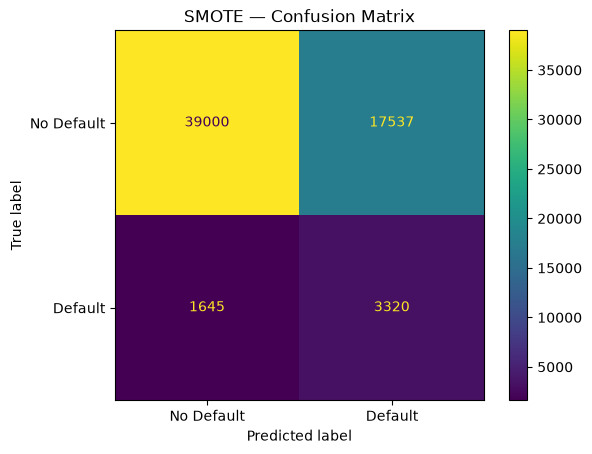

In [10]:
# ------------------------------------------------------------------
#  SMOTE + Logistic Regression
# ------------------------------------------------------------------
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=912)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE — Train shape: {X_train_smote.shape}")
print(f"Class distribution: {pd.Series(y_train_smote).value_counts().to_dict()}")

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote  = lr_smote.predict(X_test_scaled)
y_proba_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print("\n=== SMOTE Logistic Regression ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_smote):.4f}")
print(classification_report(y_test, y_pred_smote, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_smote)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("SMOTE — Confusion Matrix")
plt.show()

**DECISION TREE**

=== Full Decision Tree (unpruned) ===
Tree depth: 64
Number of leaves: 25151
ROC-AUC: 0.5381
              precision    recall  f1-score   support

  No Default       0.93      0.92      0.92     56537
     Default       0.15      0.16      0.15      4965

    accuracy                           0.86     61502
   macro avg       0.54      0.54      0.54     61502
weighted avg       0.86      0.86      0.86     61502



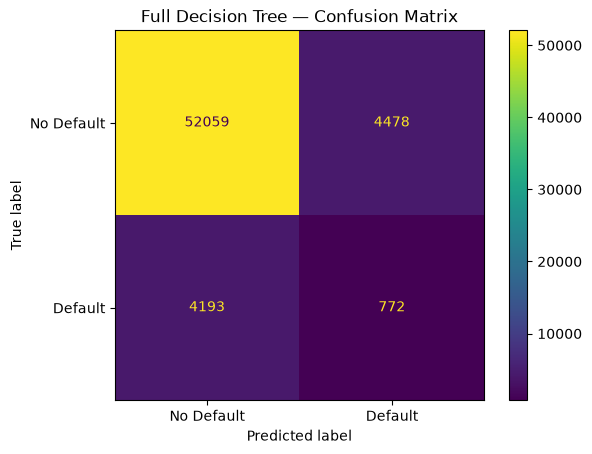

In [ ]:
# ------------------------------------------------------------------
#  Full Decision Tree (unpruned)
# ------------------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier

dt_full = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=912
)
dt_full.fit(X_train_scaled, y_train)

y_pred_dt_full  = dt_full.predict(X_test_scaled)
y_proba_dt_full = dt_full.predict_proba(X_test_scaled)[:, 1]

print("=== Full Decision Tree (unpruned) ===")
print(f"Tree depth: {dt_full.get_depth()}")
print(f"Number of leaves: {dt_full.get_n_leaves()}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dt_full):.4f}")
print(classification_report(y_test, y_pred_dt_full, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_dt_full)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Full Decision Tree — Confusion Matrix")
plt.show()

In [ ]:
# ------------------------------------------------------------------
#  Check train performance (overfit check)
# ------------------------------------------------------------------
y_pred_dt_train  = dt_full.predict(X_train_scaled)
y_proba_dt_train = dt_full.predict_proba(X_train_scaled)[:, 1]

print("=== Full Decision Tree — TRAIN performance ===")
print(f"ROC-AUC (train): {roc_auc_score(y_train, y_proba_dt_train):.4f}")
print(classification_report(y_train, y_pred_dt_train, target_names=["No Default", "Default"]))

=== Full Decision Tree — TRAIN performance ===
ROC-AUC (train): 1.0000
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00    226145
     Default       1.00      1.00      1.00     19860

    accuracy                           1.00    246005
   macro avg       1.00      1.00      1.00    246005
weighted avg       1.00      1.00      1.00    246005



**DECISION TREE (PRUNED)**

 max_depth  AUC_train  AUC_test  overfit_gap
         3     0.6891    0.6864       0.0026
         5     0.7151    0.7084       0.0066
         7     0.7357    0.7136       0.0222
        10     0.7785    0.6988       0.0797
        15     0.8842    0.6312       0.2530
        20     0.9528    0.5976       0.3553


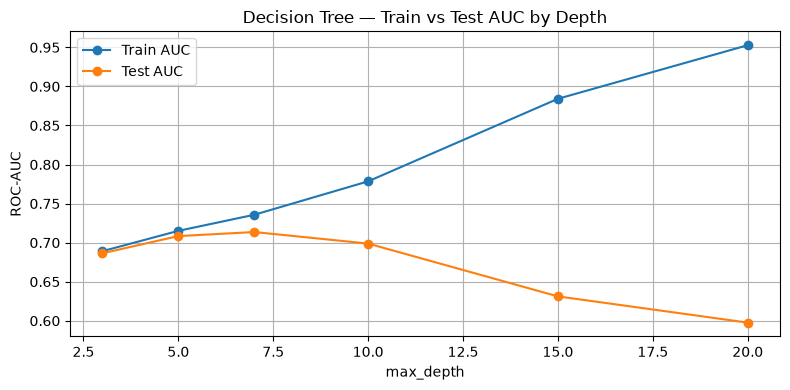

In [13]:
# ------------------------------------------------------------------
# Pruned Decision Trees (try multiple depths)
# ------------------------------------------------------------------
depths = [3, 5, 7, 10, 15, 20]
results = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=912
    )
    dt.fit(X_train_scaled, y_train)

    y_proba_train = dt.predict_proba(X_train_scaled)[:, 1]
    y_proba_test  = dt.predict_proba(X_test_scaled)[:, 1]

    auc_train = roc_auc_score(y_train, y_proba_train)
    auc_test  = roc_auc_score(y_test,  y_proba_test)

    results.append({
        "max_depth"  : depth,
        "AUC_train"  : round(auc_train, 4),
        "AUC_test"   : round(auc_test,  4),
        "overfit_gap": round(auc_train - auc_test, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot train vs test AUC across depths
plt.figure(figsize=(8, 4))
plt.plot(results_df["max_depth"], results_df["AUC_train"], marker="o", label="Train AUC")
plt.plot(results_df["max_depth"], results_df["AUC_test"],  marker="o", label="Test AUC")
plt.xlabel("max_depth")
plt.ylabel("ROC-AUC")
plt.title("Decision Tree — Train vs Test AUC by Depth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "dt_depth_auc.png", dpi=150)
plt.show()

**RANDOM FOREST**

=== Random Forest ===
ROC-AUC: 0.7446
              precision    recall  f1-score   support

  No Default       0.92      0.99      0.96     56537
     Default       0.41      0.06      0.11      4965

    accuracy                           0.92     61502
   macro avg       0.66      0.53      0.53     61502
weighted avg       0.88      0.92      0.89     61502



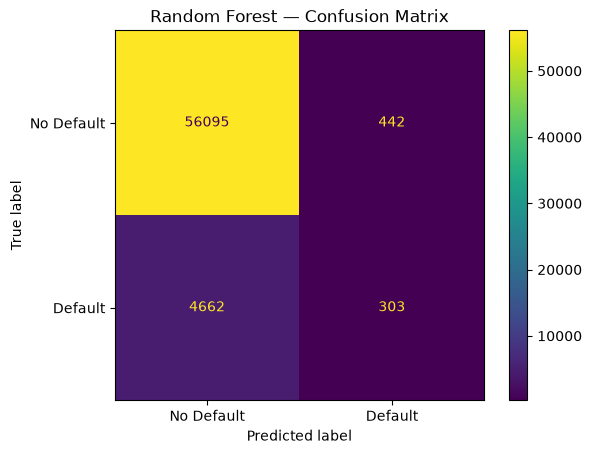

In [ ]:
# ------------------------------------------------------------------
#  Random Forest baseline
# ------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=912,
    n_jobs=-1        # use all CPU cores
)
rf.fit(X_train_scaled, y_train)

y_pred_rf  = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Random Forest — Confusion Matrix")
plt.show()

In [15]:
# ------------------------------------------------------------------
# Overfit check (train vs test)
# ------------------------------------------------------------------
y_proba_rf_train = rf.predict_proba(X_train_scaled)[:, 1]

print(f"ROC-AUC Train: {roc_auc_score(y_train, y_proba_rf_train):.4f}")
print(f"ROC-AUC Test:  {roc_auc_score(y_test,  y_proba_rf):.4f}")
print(f"Overfit gap:   {roc_auc_score(y_train, y_proba_rf_train) - roc_auc_score(y_test, y_proba_rf):.4f}")

ROC-AUC Train: 1.0000
ROC-AUC Test:  0.7446
Overfit gap:   0.2554


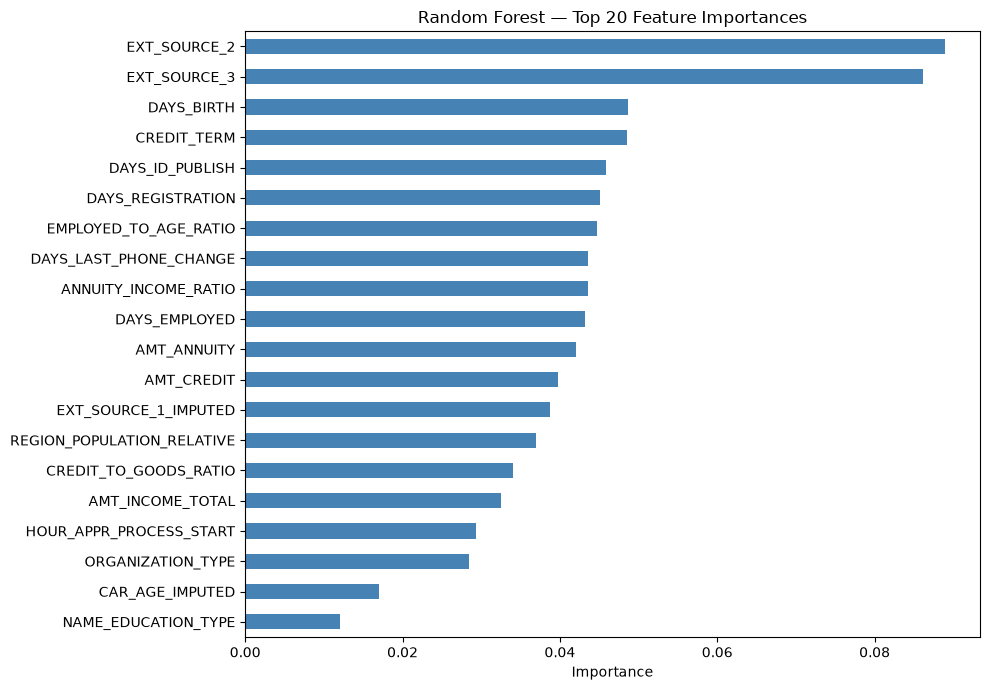

EXT_SOURCE_2                  0.088949
EXT_SOURCE_3                  0.086145
DAYS_BIRTH                    0.048606
CREDIT_TERM                   0.048544
DAYS_ID_PUBLISH               0.045891
DAYS_REGISTRATION             0.045040
EMPLOYED_TO_AGE_RATIO         0.044773
DAYS_LAST_PHONE_CHANGE        0.043617
ANNUITY_INCOME_RATIO          0.043517
DAYS_EMPLOYED                 0.043242
AMT_ANNUITY                   0.041992
AMT_CREDIT                    0.039731
EXT_SOURCE_1_IMPUTED          0.038737
REGION_POPULATION_RELATIVE    0.036955
CREDIT_TO_GOODS_RATIO         0.033996
AMT_INCOME_TOTAL              0.032567
HOUR_APPR_PROCESS_START       0.029385
ORGANIZATION_TYPE             0.028502
CAR_AGE_IMPUTED               0.016971
NAME_EDUCATION_TYPE           0.012015


In [16]:
# ------------------------------------------------------------------
# Feature importance (top 20)
# ------------------------------------------------------------------
importances = pd.Series(rf.feature_importances_, index=X_train_scaled.columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Random Forest — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "rf_feature_importance.png", dpi=150)
plt.show()

print(importances.to_string())

=== Constrained Random Forest ===
ROC-AUC Train: 0.7850
ROC-AUC Test:  0.7455
Overfit gap:   0.0396
              precision    recall  f1-score   support

  No Default       0.96      0.70      0.81     56537
     Default       0.16      0.66      0.26      4965

    accuracy                           0.70     61502
   macro avg       0.56      0.68      0.54     61502
weighted avg       0.90      0.70      0.77     61502



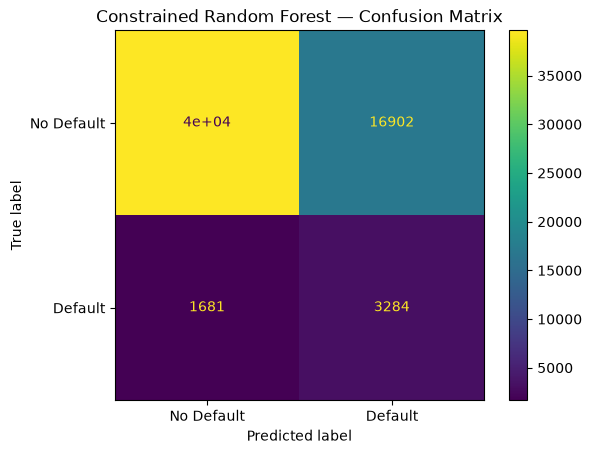

In [24]:
# ------------------------------------------------------------------
#  Constrained Random Forest
# ------------------------------------------------------------------
rf_constrained = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_leaf=100,    # each leaf must have at least 50 samples
    class_weight="balanced",
    random_state= 912,
    n_jobs=-1
)
rf_constrained.fit(X_train_scaled, y_train)

y_pred_rfc  = rf_constrained.predict(X_test_scaled)
y_proba_rfc = rf_constrained.predict_proba(X_test_scaled)[:, 1]

y_proba_rfc_train = rf_constrained.predict_proba(X_train_scaled)[:, 1]

print("=== Constrained Random Forest ===")
print(f"ROC-AUC Train: {roc_auc_score(y_train, y_proba_rfc_train):.4f}")
print(f"ROC-AUC Test:  {roc_auc_score(y_test,  y_proba_rfc):.4f}")
print(f"Overfit gap:   {roc_auc_score(y_train, y_proba_rfc_train) - roc_auc_score(y_test, y_proba_rfc):.4f}")
print(classification_report(y_test, y_pred_rfc, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_rfc)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Constrained Random Forest — Confusion Matrix")
plt.show()

**XGBOOST**

scale_pos_weight: 11.39
[0]	validation_0-auc:0.70294
[50]	validation_0-auc:0.74055
[100]	validation_0-auc:0.75107
[150]	validation_0-auc:0.75578
[200]	validation_0-auc:0.75813
[250]	validation_0-auc:0.75905
[300]	validation_0-auc:0.76009
[350]	validation_0-auc:0.76147
[400]	validation_0-auc:0.76217
[450]	validation_0-auc:0.76289
[500]	validation_0-auc:0.76306
[550]	validation_0-auc:0.76333
[589]	validation_0-auc:0.76327

=== XGBoost ===
Best iteration: 559
ROC-AUC Test:  0.7634
              precision    recall  f1-score   support

  No Default       0.96      0.72      0.82     56537
     Default       0.17      0.68      0.28      4965

    accuracy                           0.71     61502
   macro avg       0.57      0.70      0.55     61502
weighted avg       0.90      0.71      0.78     61502



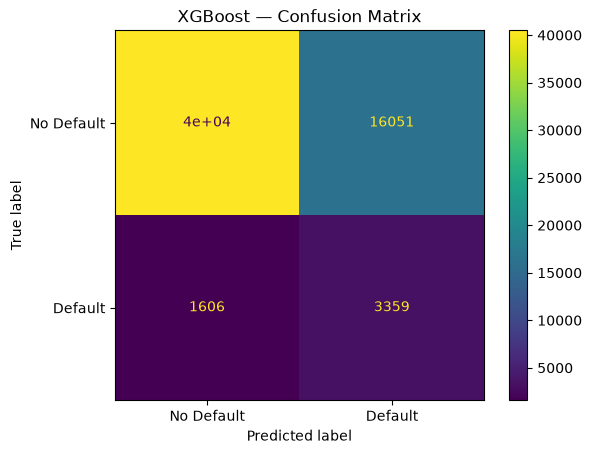

In [ ]:
# ------------------------------------------------------------------
#  XGBoost baseline
# ------------------------------------------------------------------
from xgboost import XGBClassifier

# scale_pos_weight handles imbalance — ratio of negative to positive samples
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=8,
    random_state=912,
    n_jobs=-1,
    eval_metric="auc",
    early_stopping_rounds=30,  # stop if no improvement for 50 rounds
)

xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50   # print AUC every 50 trees
)

y_pred_xgb  = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("\n=== XGBoost ===")
print(f"Best iteration: {xgb.best_iteration}")
print(f"ROC-AUC Test:  {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("XGBoost — Confusion Matrix")
plt.show()

In [58]:
# ------------------------------------------------------------------
# Cell 2 — Overfit check
# ------------------------------------------------------------------
y_proba_xgb_train = xgb.predict_proba(X_train_scaled)[:, 1]

print(f"ROC-AUC Train: {roc_auc_score(y_train, y_proba_xgb_train):.4f}")
print(f"ROC-AUC Test:  {roc_auc_score(y_test,  y_proba_xgb):.4f}")
print(f"Overfit gap:   {roc_auc_score(y_train, y_proba_xgb_train) - roc_auc_score(y_test, y_proba_xgb):.4f}")

ROC-AUC Train: 0.7995
ROC-AUC Test:  0.7634
Overfit gap:   0.0362


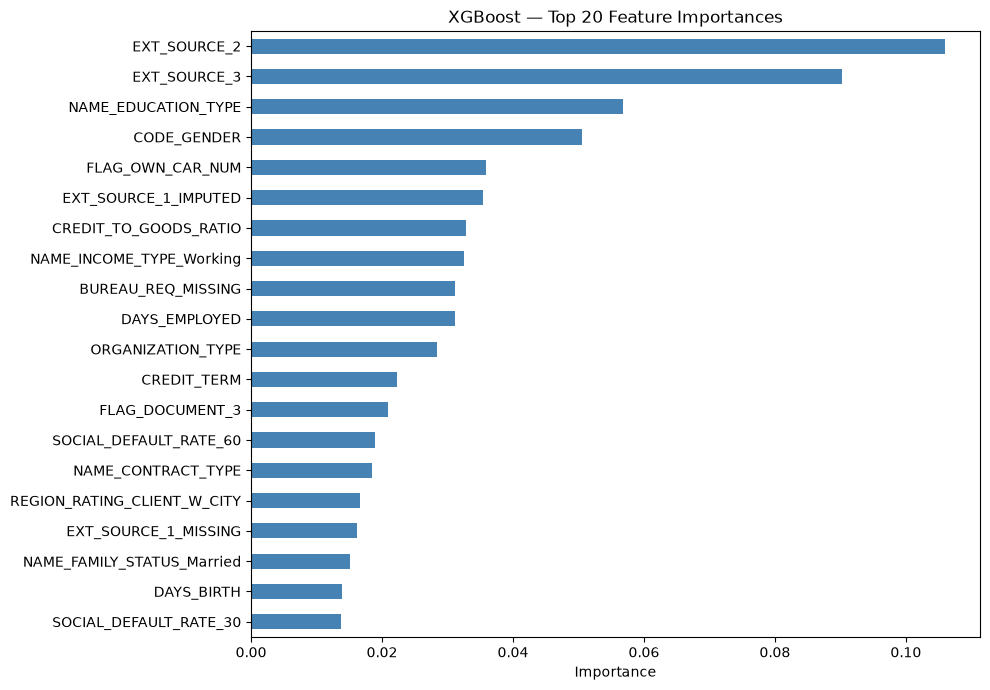

EXT_SOURCE_2                   0.106020
EXT_SOURCE_3                   0.090293
NAME_EDUCATION_TYPE            0.056799
CODE_GENDER                    0.050492
FLAG_OWN_CAR_NUM               0.035905
EXT_SOURCE_1_IMPUTED           0.035440
CREDIT_TO_GOODS_RATIO          0.032828
NAME_INCOME_TYPE_Working       0.032477
BUREAU_REQ_MISSING             0.031181
DAYS_EMPLOYED                  0.031100
ORGANIZATION_TYPE              0.028327
CREDIT_TERM                    0.022361
FLAG_DOCUMENT_3                0.020839
SOCIAL_DEFAULT_RATE_60         0.018936
NAME_CONTRACT_TYPE             0.018493
REGION_RATING_CLIENT_W_CITY    0.016592
EXT_SOURCE_1_MISSING           0.016237
NAME_FAMILY_STATUS_Married     0.015056
DAYS_BIRTH                     0.013884
SOCIAL_DEFAULT_RATE_30         0.013747


In [59]:
# ------------------------------------------------------------------
# Cell 3 — Feature importance
# ------------------------------------------------------------------
importances = pd.Series(xgb.feature_importances_, index=X_train_scaled.columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("XGBoost — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "xgb_feature_importance.png", dpi=150)
plt.show()

print(importances.to_string())

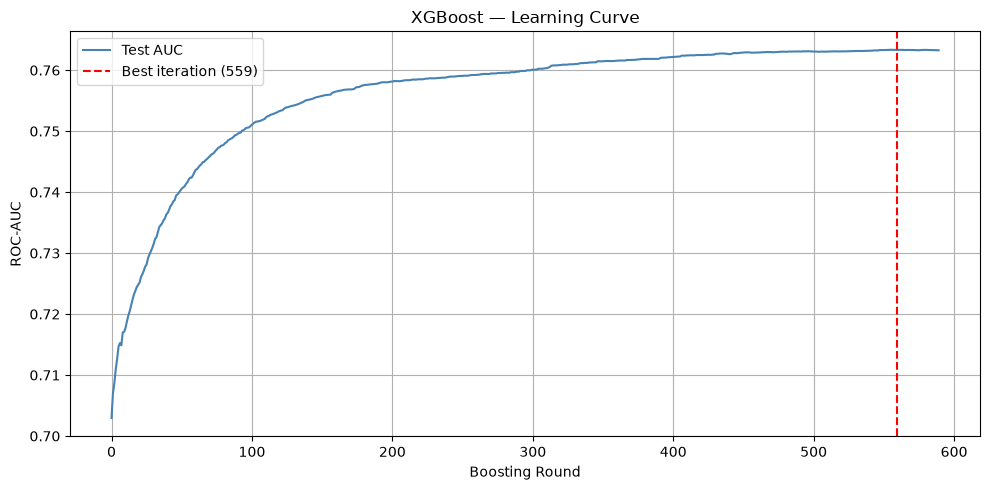

In [60]:
# ------------------------------------------------------------------
# Cell 4 — Learning curve (train vs test AUC over boosting rounds)
# ------------------------------------------------------------------
results = xgb.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results["validation_0"]["auc"], label="Test AUC", color="steelblue")
plt.axvline(xgb.best_iteration, color="red", linestyle="--", label=f"Best iteration ({xgb.best_iteration})")
plt.xlabel("Boosting Round")
plt.ylabel("ROC-AUC")
plt.title("XGBoost — Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "xgb_learning_curve.png", dpi=150)
plt.show()